# NSynth AFTER Timbre Embedding Visualization

This notebook loads the pre-extracted `AFTER_Timbre` embeddings from NSynth and visualizes them using:

- PCA
- t-SNE
- UMAP
- K-Means clustering

The goal is to inspect whether the new extracted embeddings show visible structure with respect to:

- `instrument_family`
- `qualities`
- unsupervised clusters

This notebook is meant to be independent from the Synesis linear probing notebook.


## 1. Setup

Run this first. If you are using Google Colab, mount Google Drive before loading the dataset.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import json
import random
import warnings

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

SEED = 33
random.seed(SEED)
np.random.seed(SEED)

plt.rcParams["figure.dpi"] = 120

print("Setup done.")

Mounted at /content/drive
Setup done.


## 2. Configuration

Change these variables depending on which split and feature folder you want to visualize.

Recommended starting point:
- `SPLIT = "test"` for a smaller and cleaner first visualization.
- Later try `"train"` with `MAX_SAMPLES = 2000` or a balanced sample.


In [ ]:
# Dataset root where your NSynth folders are stored
DATASET_ROOT = Path("/content/drive/MyDrive/datasets/nsynth")

# Feature folder containing the extracted AFTER timbre embeddings
FEATURE = "AFTER_Timbre"   # change this if your folder has a different name

# Split to visualize: "train", "validation", or "test"
SPLIT = "test"

# Limit number of points for visualization.
# Use None to load all examples from the selected split.
# For t-SNE/UMAP, 1000-3000 is usually a good range.
MAX_SAMPLES = 2000

# If True, sample approximately the same number of examples per instrument family.
BALANCED_BY_INSTRUMENT = True

# K-Means clusters
N_CLUSTERS = 6

# Output folder for saving figures
OUTPUT_DIR = Path("./figures_after_visualization")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATASET_ROOT:", DATASET_ROOT)
print("SPLIT:", SPLIT)
print("FEATURE:", FEATURE)
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())

DATASET_ROOT: /content/drive/MyDrive/datasets/nsynth
SPLIT: test
FEATURE: AFTER_Timbre
OUTPUT_DIR: /content/figures_after_visualization


## 3. Helper functions

These functions load the embeddings and metadata from NSynth.

The expected folder structure is:

```text
DATASET_ROOT/
    train/
        examples.json
        AFTER_Timbre/
            note_id.pt
    validation/
        examples.json
        AFTER_Timbre/
            note_id.pt
    test/
        examples.json
        AFTER_Timbre/
            note_id.pt
```

If your folders are named differently, change `DATASET_ROOT`, `SPLIT`, or `FEATURE` above.


In [ ]:
NSYNTH_QUALITY_NAMES = [
    "bright",
    "dark",
    "distortion",
    "fast_decay",
    "long_release",
    "multiphonic",
    "nonlinear_env",
    "percussive",
    "reverb",
    "tempo-synced",
]

NSYNTH_INSTRUMENT_FAMILY_NAMES = {
    0: "bass",
    1: "brass",
    2: "flute",
    3: "guitar",
    4: "keyboard",
    5: "mallet",
    6: "organ",
    7: "reed",
    8: "string",
    9: "synth_lead",
    10: "vocal",
}


def get_instrument_family(example):
    """Return instrument family as string, with fallbacks."""
    if "instrument_family_str" in example:
        return example["instrument_family_str"]

    if "instrument_family" in example:
        return NSYNTH_INSTRUMENT_FAMILY_NAMES.get(
            int(example["instrument_family"]),
            str(example["instrument_family"])
        )

    return "unknown"


def get_qualities_str(example):
    """Return qualities as a comma-separated string."""
    qualities = example.get("qualities", None)

    if qualities is None:
        return ""

    if isinstance(qualities, dict):
        active = [name for name, value in qualities.items() if int(value) == 1]
        return ", ".join(active)

    if isinstance(qualities, list):
        active = [
            NSYNTH_QUALITY_NAMES[i]
            for i, value in enumerate(qualities)
            if int(value) == 1 and i < len(NSYNTH_QUALITY_NAMES)
        ]
        return ", ".join(active)

    return str(qualities)


def get_primary_quality(quality_str):
    """Keep the first quality when several are present."""
    if not isinstance(quality_str, str):
        return "unknown"

    if quality_str.strip() == "":
        return "unknown"

    return quality_str.split(",")[0].strip()


def load_embedding(path):
    """Load a .pt embedding and flatten it to a 1D vector."""
    emb = torch.load(path, map_location="cpu", weights_only=False)

    if isinstance(emb, dict):
        # In case features were saved in a dictionary
        if "feature" in emb:
            emb = emb["feature"]
        elif "embedding" in emb:
            emb = emb["embedding"]
        else:
            raise ValueError(f"Unsupported dict keys in {path}: {list(emb.keys())}")

    if isinstance(emb, np.ndarray):
        emb = torch.tensor(emb)

    if not torch.is_tensor(emb):
        raise TypeError(f"Unsupported embedding type at {path}: {type(emb)}")

    return emb.detach().cpu().float().reshape(-1).numpy()


def sample_note_ids(metadata, max_samples=None, balanced_by_instrument=True, seed=33):
    """Sample note ids, optionally balanced by instrument family."""
    note_ids = list(metadata.keys())

    if max_samples is None or max_samples >= len(note_ids):
        return note_ids

    rng = random.Random(seed)

    if not balanced_by_instrument:
        return rng.sample(note_ids, max_samples)

    by_family = {}
    for note_id in note_ids:
        family = get_instrument_family(metadata[note_id])
        by_family.setdefault(family, []).append(note_id)

    families = sorted(by_family.keys())
    per_family = max(1, max_samples // len(families))

    sampled = []
    used = set()
    for family in families:
        ids = by_family[family]
        rng.shuffle(ids)
        chosen = ids[:per_family]
        sampled.extend(chosen)
        used.update(chosen)

    if len(sampled) < max_samples:
        remaining = [n for n in note_ids if n not in used]
        rng.shuffle(remaining)
        sampled.extend(remaining[:max_samples - len(sampled)])

    sampled = sampled[:max_samples]
    rng.shuffle(sampled)
    return sampled


def load_nsynth_after_embeddings(
    dataset_root,
    split,
    feature,
    max_samples=None,
    balanced_by_instrument=True,
    seed=33,
):
    split_root = Path(dataset_root) / split
    metadata_path = split_root / "examples.json"
    feature_root = split_root / feature

    if not metadata_path.exists():
        raise FileNotFoundError(f"Could not find metadata file: {metadata_path}")

    if not feature_root.exists():
        raise FileNotFoundError(f"Could not find feature folder: {feature_root}")

    with open(metadata_path, "r") as f:
        metadata = json.load(f)

    selected_note_ids = sample_note_ids(
        metadata,
        max_samples=max_samples,
        balanced_by_instrument=balanced_by_instrument,
        seed=seed,
    )

    embeddings = []
    file_names = []
    instrument_family_str = []
    qualities_str = []
    missing = []

    for note_id in selected_note_ids:
        feature_path = feature_root / f"{note_id}.pt"

        if not feature_path.exists():
            missing.append(str(feature_path))
            continue

        example = metadata[note_id]

        embeddings.append(load_embedding(feature_path))
        file_names.append(note_id)
        instrument_family_str.append(get_instrument_family(example))
        qualities_str.append(get_qualities_str(example))

    if len(missing) > 0:
        warnings.warn(
            f"{len(missing)} feature files were missing. "
            f"First missing file: {missing[0]}"
        )

    if len(embeddings) == 0:
        raise RuntimeError("No embeddings were loaded. Check DATASET_ROOT, SPLIT and FEATURE.")

    embeddings = np.stack(embeddings)

    df_meta = pd.DataFrame({
        "filename": file_names,
        "instrument": instrument_family_str,
        "qualities": qualities_str,
        "quality": [get_primary_quality(q) for q in qualities_str],
    })

    return embeddings, df_meta


print("Helper functions loaded.")

Helper functions loaded.


## 4. Load embeddings

This cell loads the selected split and prints a quick summary.


In [ ]:
embeddings, df_meta = load_nsynth_after_embeddings(
    dataset_root=DATASET_ROOT,
    split=SPLIT,
    feature=FEATURE,
    max_samples=MAX_SAMPLES,
    balanced_by_instrument=BALANCED_BY_INSTRUMENT,
    seed=SEED,
)

print("Embeddings shape:", embeddings.shape)
print("Metadata shape:", df_meta.shape)

display(df_meta.head())

print("\nInstrument counts:")
display(df_meta["instrument"].value_counts())

print("\nPrimary quality counts:")
display(df_meta["quality"].value_counts())

Embeddings shape: (2000, 6)
Metadata shape: (2000, 4)


,filename,instrument,qualities,quality
0,mallet_acoustic_062-061-100,mallet,"dark, multiphonic",dark
1,keyboard_electronic_003-075-025,keyboard,,unknown
2,mallet_acoustic_056-106-025,mallet,bright,bright
3,mallet_acoustic_062-040-100,mallet,"dark, long_release, multiphonic",dark
4,brass_acoustic_046-059-127,brass,bright,bright



Instrument counts:


,count
instrument,
bass,342
keyboard,319
guitar,283
organ,255
string,165
reed,153
mallet,143
brass,143
flute,109



Primary quality counts:


,count
quality,
unknown,449
dark,355
bright,324
distortion,288
fast_decay,212
reverb,206
long_release,129
percussive,17
tempo-synced,8


## 5. Generic plotting utilities

These functions are reused for PCA, t-SNE and UMAP.


In [ ]:
def add_kmeans_clusters(df, coordinates, n_clusters=6, random_state=33):
    """Add K-Means cluster labels to a DataFrame."""
    kmeans = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    df = df.copy()
    df["cluster"] = kmeans.fit_predict(coordinates)
    return df


def plot_2d_by_category(
    df,
    x_col,
    y_col,
    category_col,
    title,
    save_path=None,
    point_size=35,
    alpha=0.75,
):
    plt.figure(figsize=(10, 8))

    categories = sorted(df[category_col].unique(), key=lambda x: str(x))
    cmap = plt.cm.get_cmap("tab20", len(categories))

    for i, cat in enumerate(categories):
        subset = df[df[category_col] == cat]
        plt.scatter(
            subset[x_col],
            subset[y_col],
            s=point_size,
            alpha=alpha,
            color=cmap(i),
            label=str(cat),
        )

    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(title)
    plt.legend(title=category_col, bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight", dpi=300)
        print("Saved:", save_path)

    plt.show()


def make_projection_dataframe(df_meta, coords, prefix, cluster_coords=None):
    """Create a plotting DataFrame for a 2D projection."""
    df = df_meta.copy()
    df[f"{prefix}1"] = coords[:, 0]
    df[f"{prefix}2"] = coords[:, 1]

    if cluster_coords is None:
        cluster_coords = coords

    df = add_kmeans_clusters(
        df,
        coordinates=cluster_coords,
        n_clusters=N_CLUSTERS,
        random_state=SEED,
    )

    return df


def plot_projection_set(df, prefix, method_name):
    """Plot by instrument, primary quality and K-Means cluster."""
    x_col = f"{prefix}1"
    y_col = f"{prefix}2"

    plot_2d_by_category(
        df,
        x_col=x_col,
        y_col=y_col,
        category_col="instrument",
        title=f"{method_name} of AFTER timbre embeddings colored by instrument family",
        save_path=OUTPUT_DIR / f"{method_name.lower().replace('-', '')}_by_instrument.png",
    )

    plot_2d_by_category(
        df,
        x_col=x_col,
        y_col=y_col,
        category_col="quality",
        title=f"{method_name} of AFTER timbre embeddings colored by primary quality",
        save_path=OUTPUT_DIR / f"{method_name.lower().replace('-', '')}_by_quality.png",
    )

    plot_2d_by_category(
        df,
        x_col=x_col,
        y_col=y_col,
        category_col="cluster",
        title=f"{method_name} of AFTER timbre embeddings colored by K-Means clusters (k={N_CLUSTERS})",
        save_path=OUTPUT_DIR / f"{method_name.lower().replace('-', '')}_by_cluster.png",
    )


print("Plotting utilities loaded.")

Plotting utilities loaded.


## 6. PCA

PCA is deterministic and fast. It is useful as a first global view of the embedding space.


Explained variance ratio: [0.39442763 0.25126055]
Total explained variance: 0.6456882


,filename,instrument,qualities,quality,PCA1,PCA2,cluster
0,mallet_acoustic_062-061-100,mallet,"dark, multiphonic",dark,0.637803,-0.047312,5
1,keyboard_electronic_003-075-025,keyboard,,unknown,0.142563,0.178885,5
2,mallet_acoustic_056-106-025,mallet,bright,bright,-0.837962,0.397296,3
3,mallet_acoustic_062-040-100,mallet,"dark, long_release, multiphonic",dark,0.627033,-0.272333,1
4,brass_acoustic_046-059-127,brass,bright,bright,-0.801140,0.146049,3


/tmp/ipykernel_7310/2467826214.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(categories))


Saved: figures_after_visualization/pca_by_instrument.png


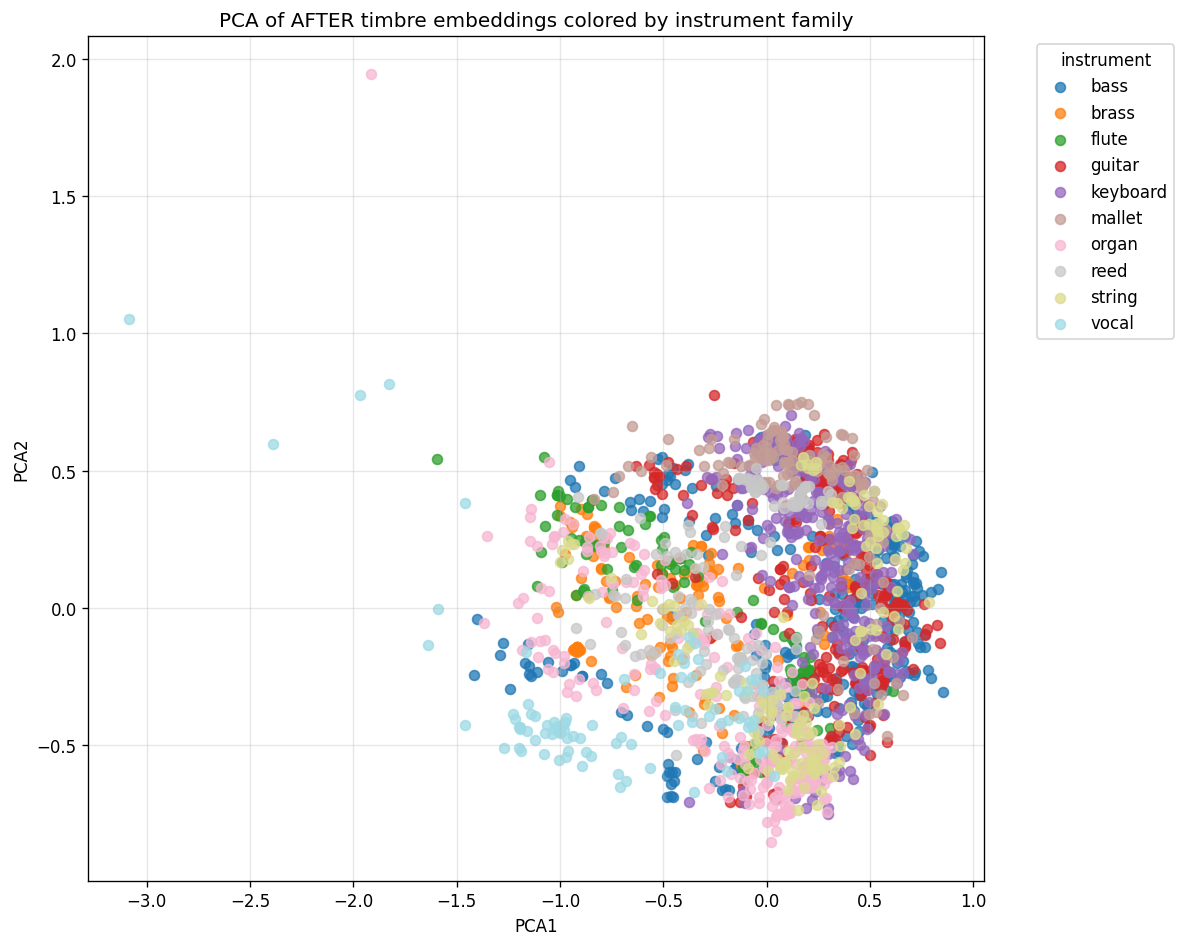

Saved: figures_after_visualization/pca_by_quality.png


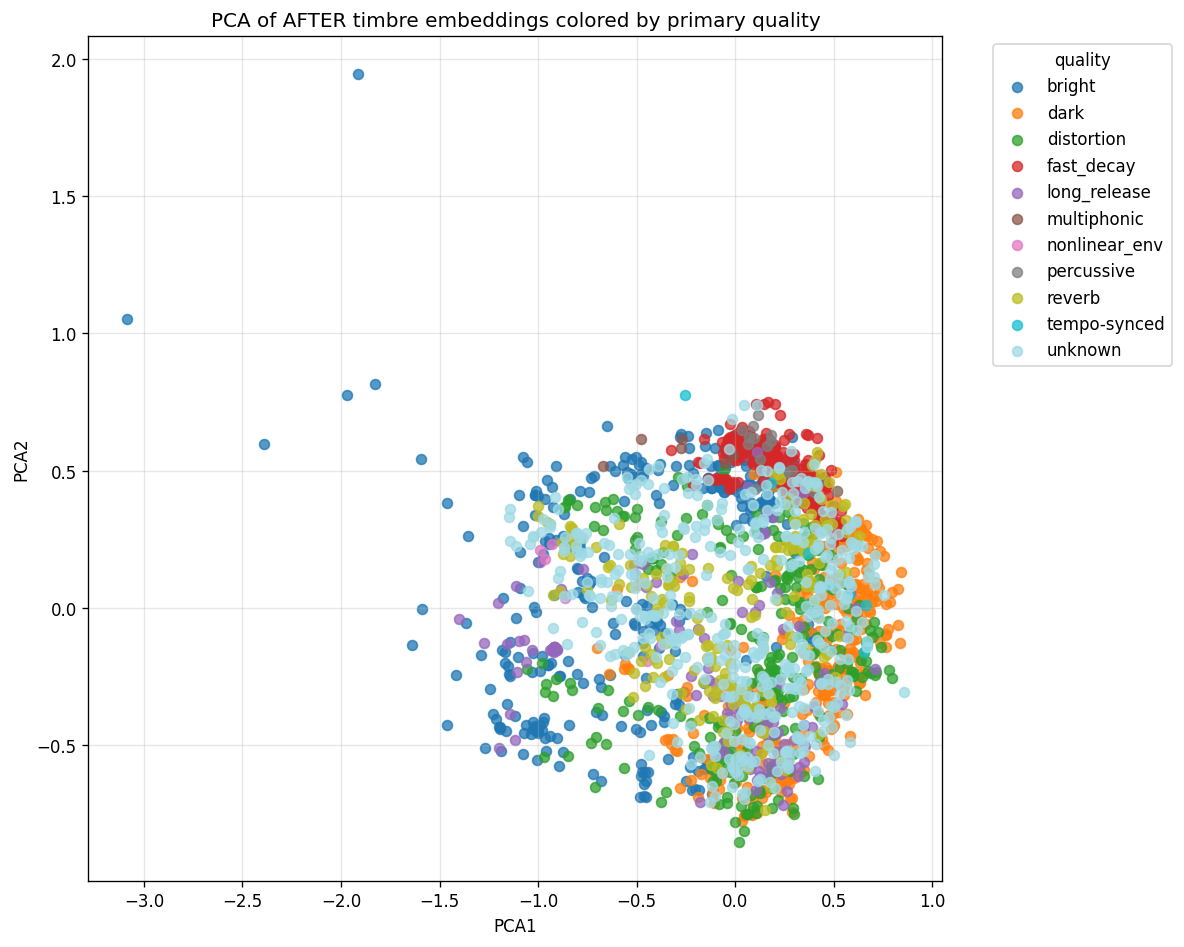

Saved: figures_after_visualization/pca_by_cluster.png


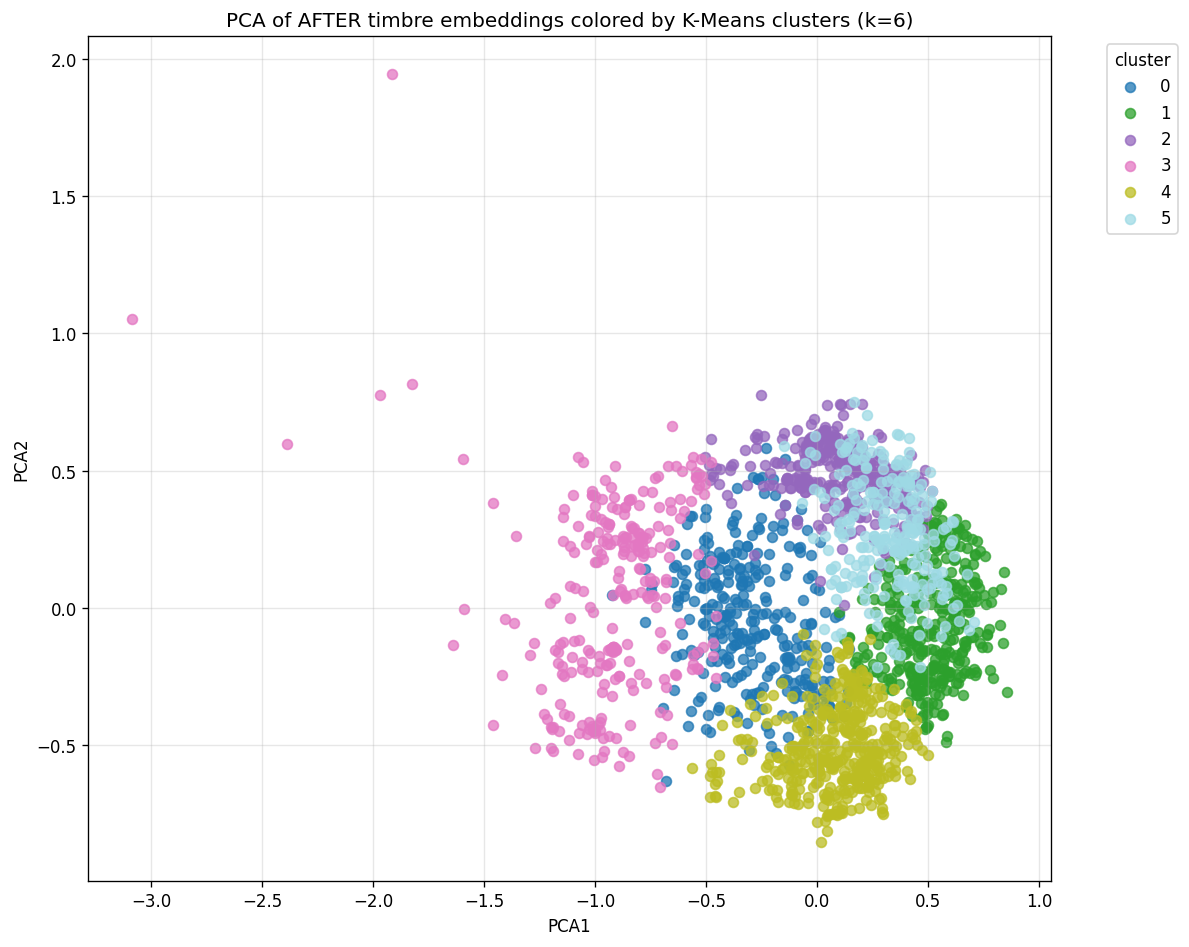

In [ ]:
pca = PCA(n_components=2, random_state=SEED)
embeddings_pca = pca.fit_transform(embeddings)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total explained variance:", pca.explained_variance_ratio_.sum())

df_pca = make_projection_dataframe(
    df_meta=df_meta,
    coords=embeddings_pca,
    prefix="PCA",
    cluster_coords=embeddings,  # K-Means on original embeddings, not the 2D projection
)

display(df_pca.head())

plot_projection_set(df_pca, prefix="PCA", method_name="PCA")

In [ ]:
def remove_projection_outliers(df, x_col, y_col, low=1, high=99):
    x_low, x_high = df[x_col].quantile([low / 100, high / 100])
    y_low, y_high = df[y_col].quantile([low / 100, high / 100])

    return df[
        (df[x_col] >= x_low) & (df[x_col] <= x_high) &
        (df[y_col] >= y_low) & (df[y_col] <= y_high)
    ].copy()

df_pca_zoom = remove_projection_outliers(
    df_pca,
    x_col="PCA1",
    y_col="PCA2",
    low=1,
    high=99,
)

print("Original PCA points:", len(df_pca))
print("Zoomed PCA points:", len(df_pca_zoom))
print("Removed points:", len(df_pca) - len(df_pca_zoom))

Original PCA points: 2000
Zoomed PCA points: 1924
Removed points: 76


/tmp/ipykernel_7310/2467826214.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(categories))


Saved: figures_after_visualization/pca_by_instrument_zoom.png


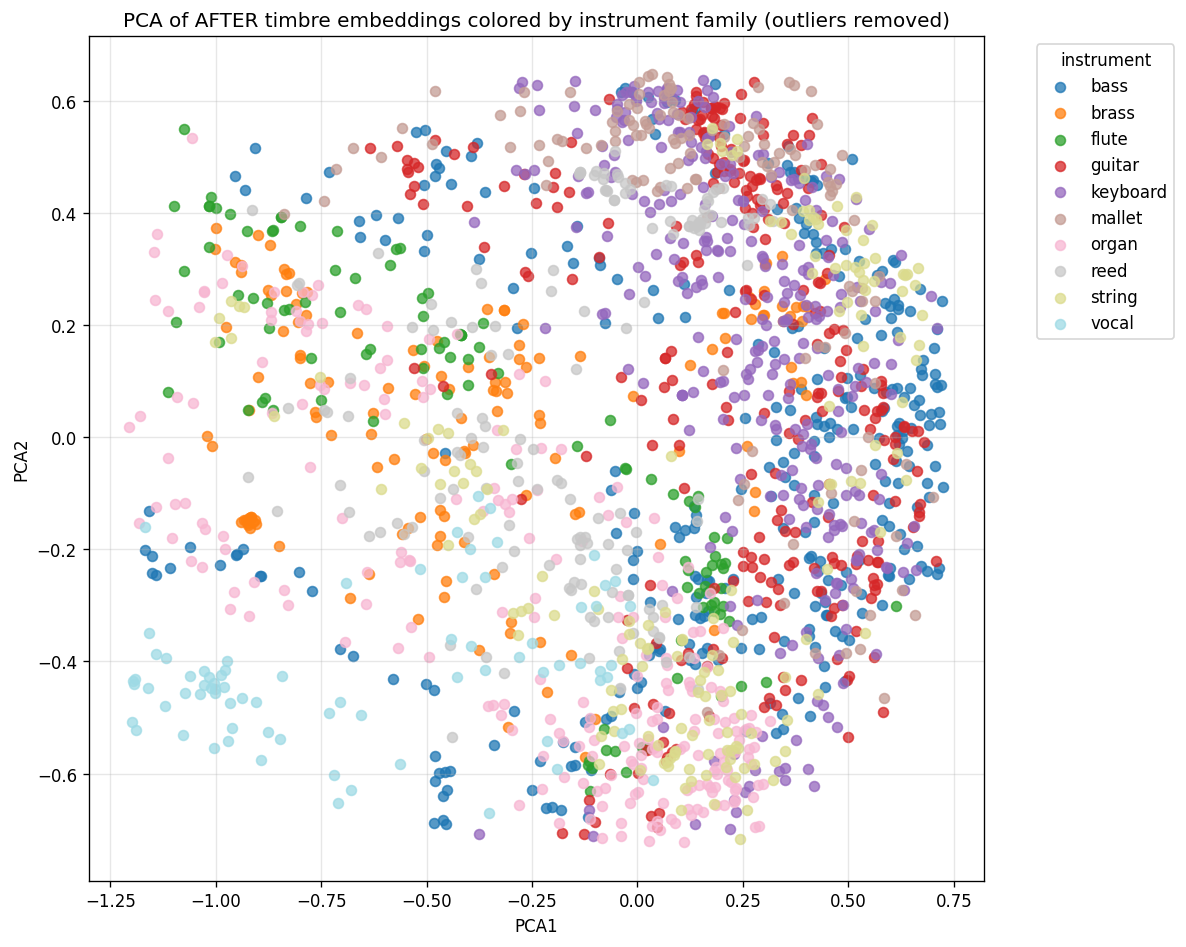

Saved: figures_after_visualization/pca_by_quality_zoom.png


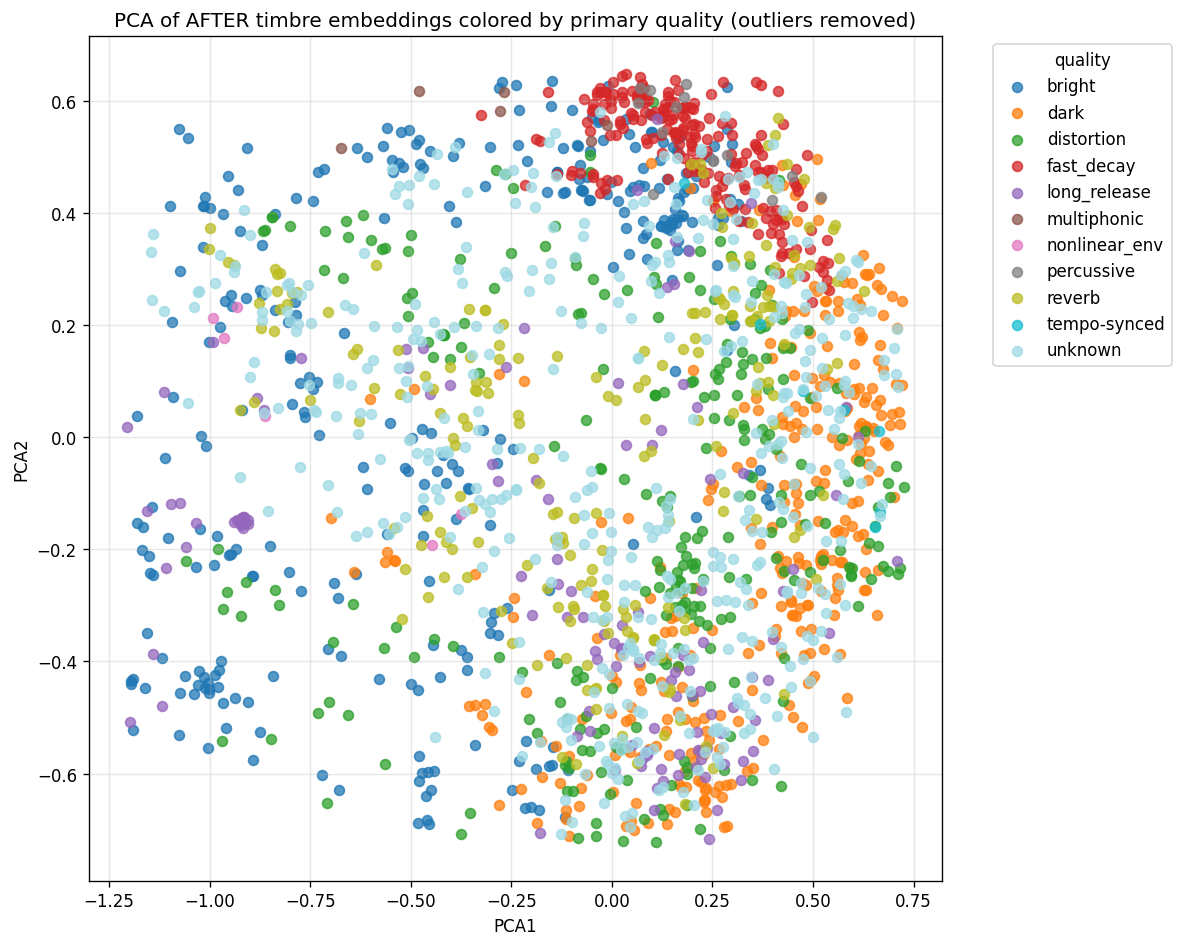

In [ ]:
plot_2d_by_category(
    df_pca_zoom,
    x_col="PCA1",
    y_col="PCA2",
    category_col="instrument",
    title="PCA of AFTER timbre embeddings colored by instrument family (outliers removed)",
    save_path=OUTPUT_DIR / "pca_by_instrument_zoom.png",
)

plot_2d_by_category(
    df_pca_zoom,
    x_col="PCA1",
    y_col="PCA2",
    category_col="quality",
    title="PCA of AFTER timbre embeddings colored by primary quality (outliers removed)",
    save_path=OUTPUT_DIR / "pca_by_quality_zoom.png",
)

## 7. t-SNE

t-SNE can be slow for many points. If this cell takes too long, reduce `MAX_SAMPLES` in the configuration section.


t-SNE shape: (2000, 2)


,filename,instrument,qualities,quality,TSNE1,TSNE2,cluster
0,mallet_acoustic_062-061-100,mallet,"dark, multiphonic",dark,13.914582,3.482249,5
1,keyboard_electronic_003-075-025,keyboard,,unknown,-2.380162,10.665115,5
2,mallet_acoustic_056-106-025,mallet,bright,bright,-45.027893,16.545856,3
3,mallet_acoustic_062-040-100,mallet,"dark, long_release, multiphonic",dark,30.152332,-8.842398,1
4,brass_acoustic_046-059-127,brass,bright,bright,-39.906258,16.062847,3


/tmp/ipykernel_7310/2467826214.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(categories))


Saved: figures_after_visualization/tsne_by_instrument.png


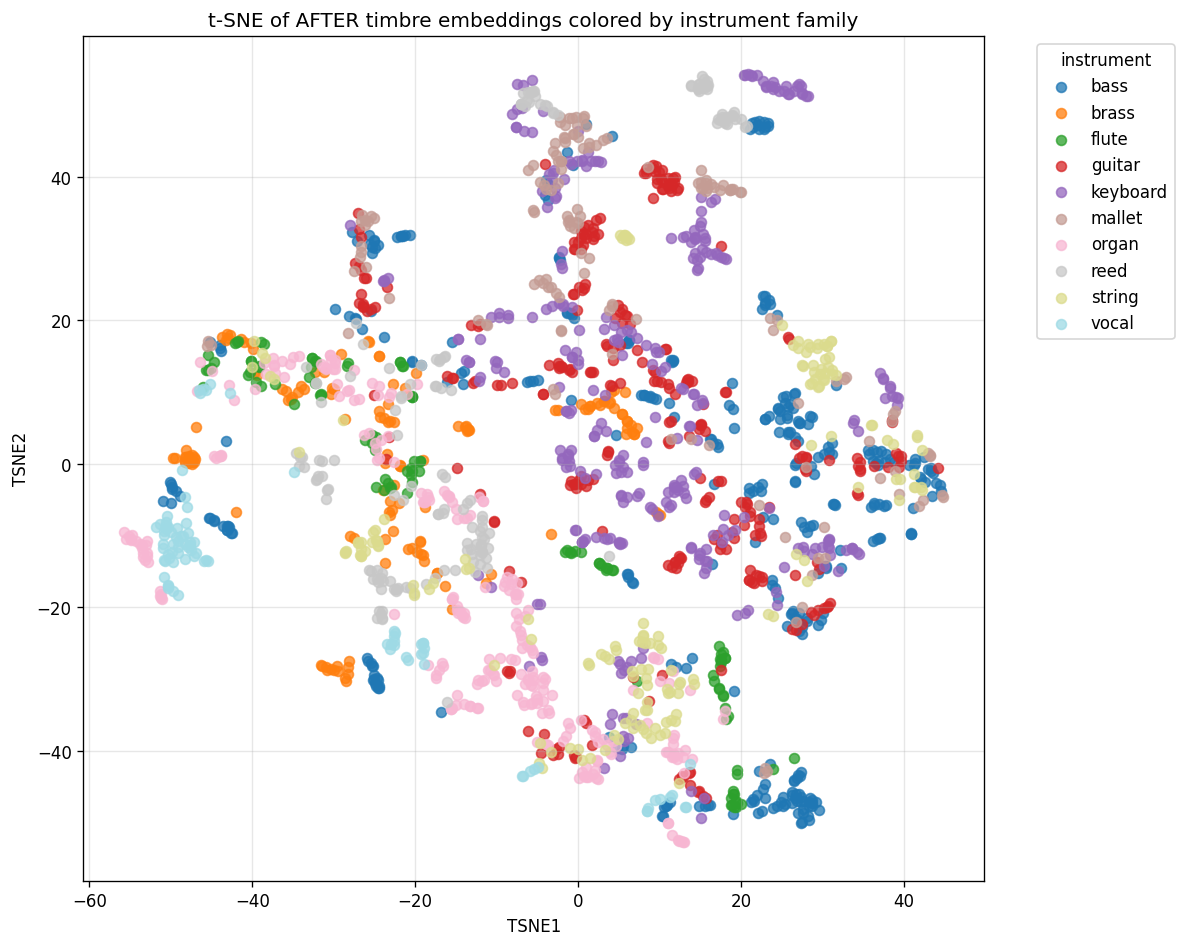

Saved: figures_after_visualization/tsne_by_quality.png


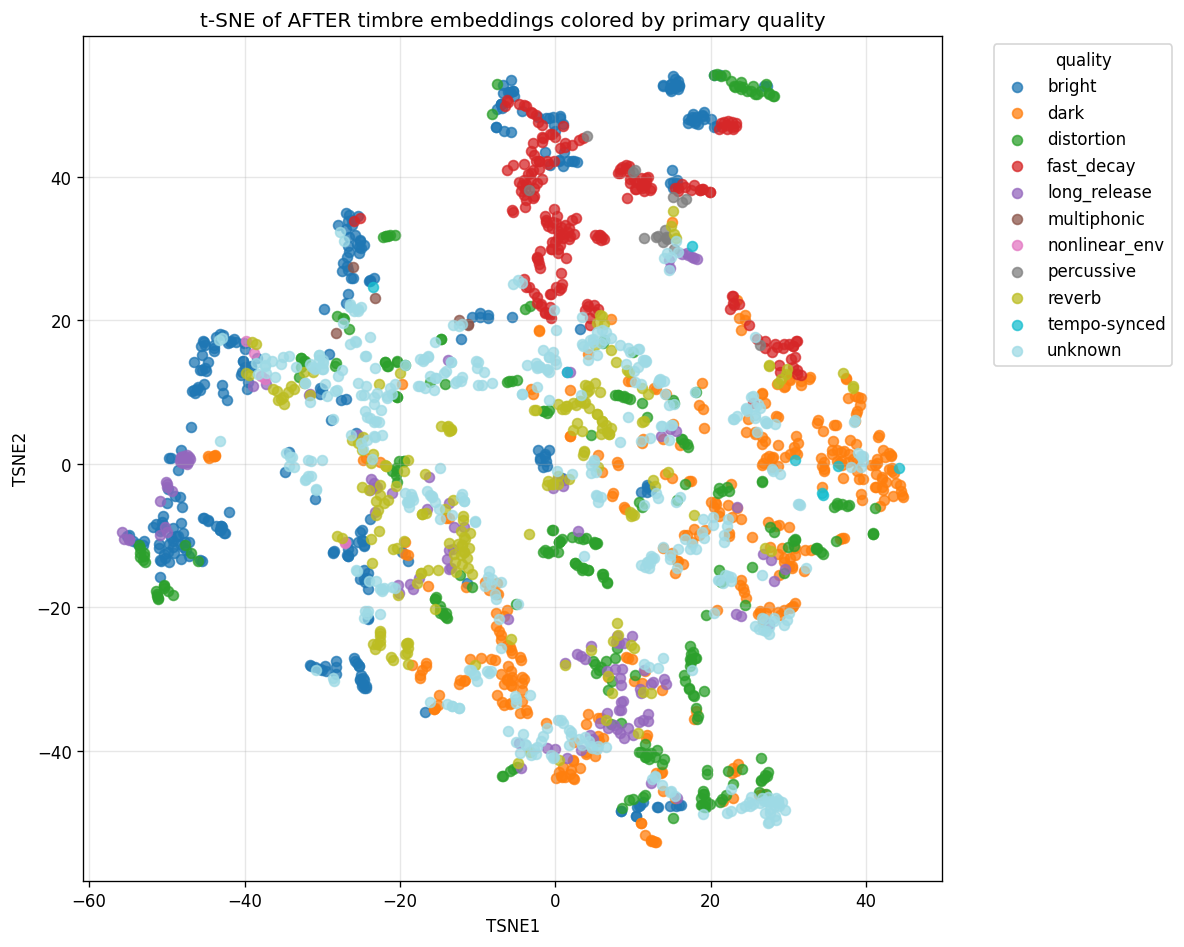

Saved: figures_after_visualization/tsne_by_cluster.png


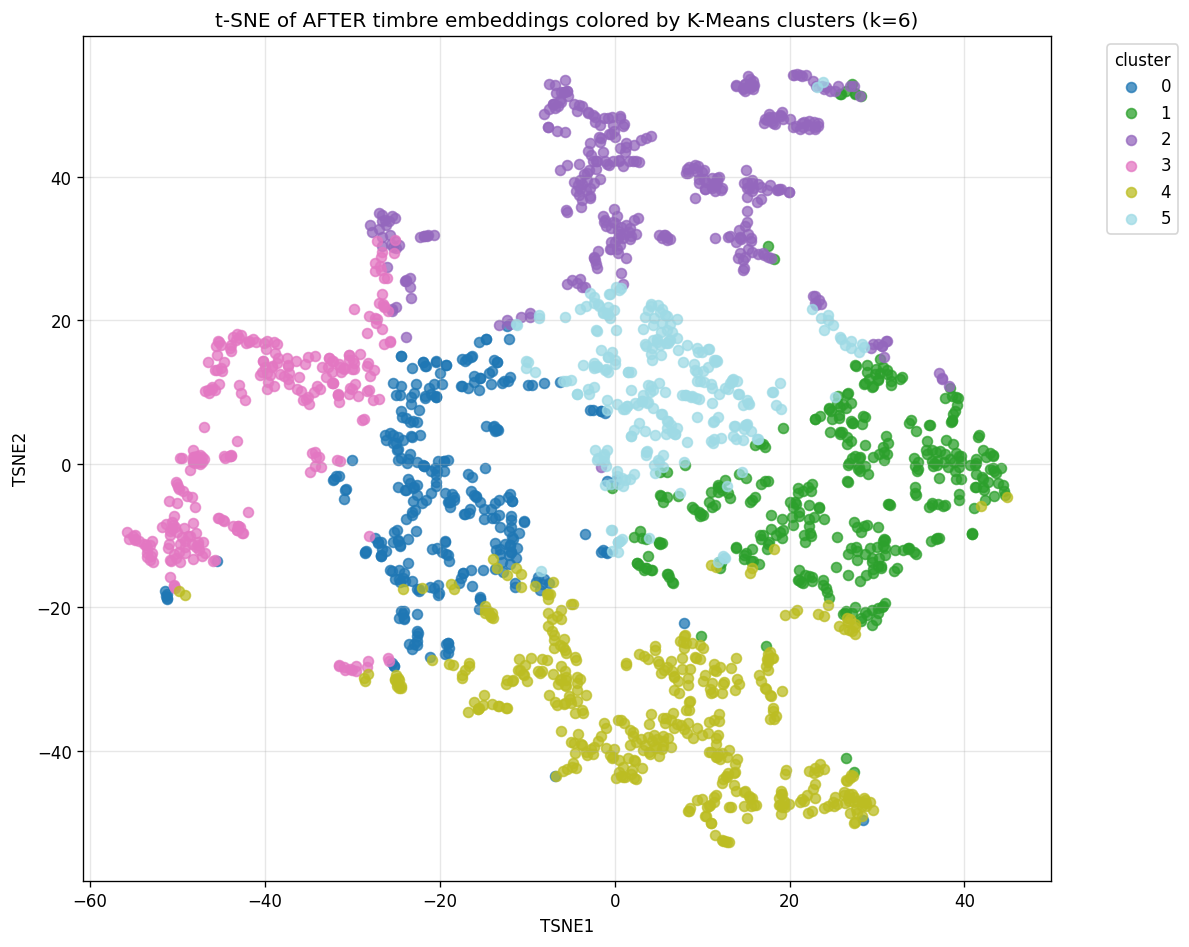

In [ ]:
tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=SEED,
)

embeddings_tsne = tsne.fit_transform(embeddings)

print("t-SNE shape:", embeddings_tsne.shape)

df_tsne = make_projection_dataframe(
    df_meta=df_meta,
    coords=embeddings_tsne,
    prefix="TSNE",
    cluster_coords=embeddings,  # K-Means on original embeddings
)

display(df_tsne.head())

plot_projection_set(df_tsne, prefix="TSNE", method_name="t-SNE")

## 8. UMAP

If `umap-learn` is not installed, run the installation cell first.


In [ ]:
# Run this only if UMAP is not installed:
# !pip install umap-learn

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP shape: (2000, 2)


,filename,instrument,qualities,quality,UMAP1,UMAP2,cluster
0,mallet_acoustic_062-061-100,mallet,"dark, multiphonic",dark,3.362992,3.179962,5
1,keyboard_electronic_003-075-025,keyboard,,unknown,3.326749,5.224636,5
2,mallet_acoustic_056-106-025,mallet,bright,bright,6.571313,10.517667,3
3,mallet_acoustic_062-040-100,mallet,"dark, long_release, multiphonic",dark,4.697020,0.149729,1
4,brass_acoustic_046-059-127,brass,bright,bright,6.243420,10.048673,3


/tmp/ipykernel_7310/2467826214.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(categories))


Saved: figures_after_visualization/umap_by_instrument.png


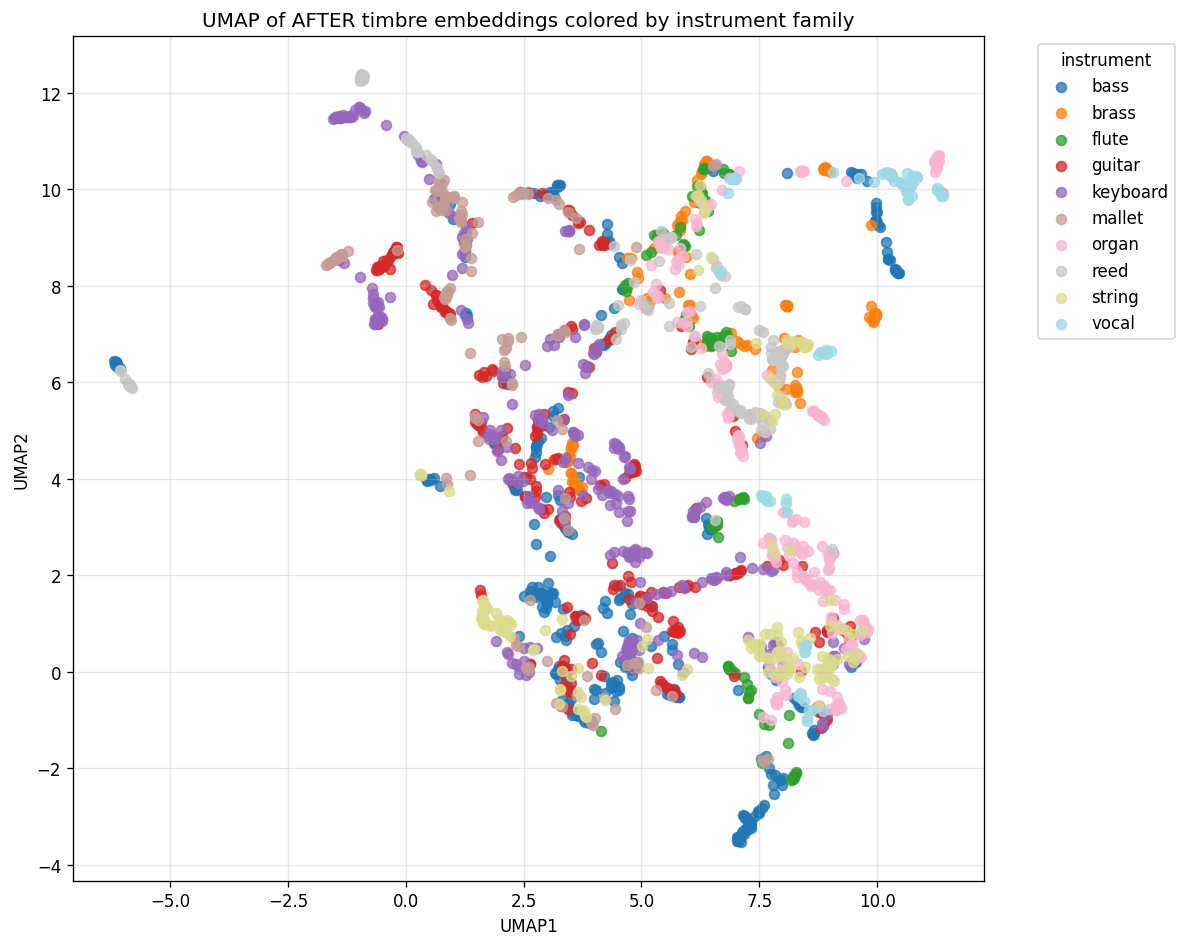

Saved: figures_after_visualization/umap_by_quality.png


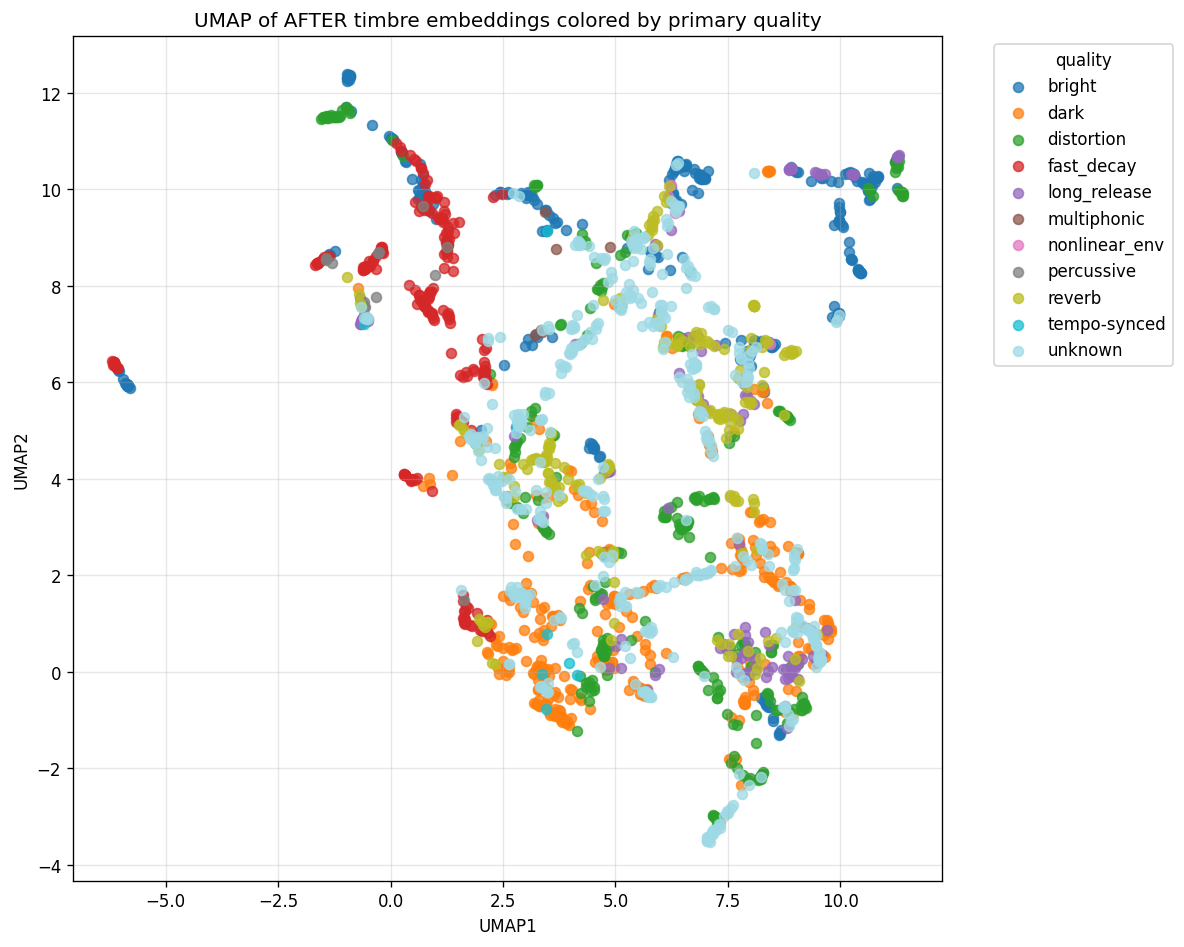

Saved: figures_after_visualization/umap_by_cluster.png


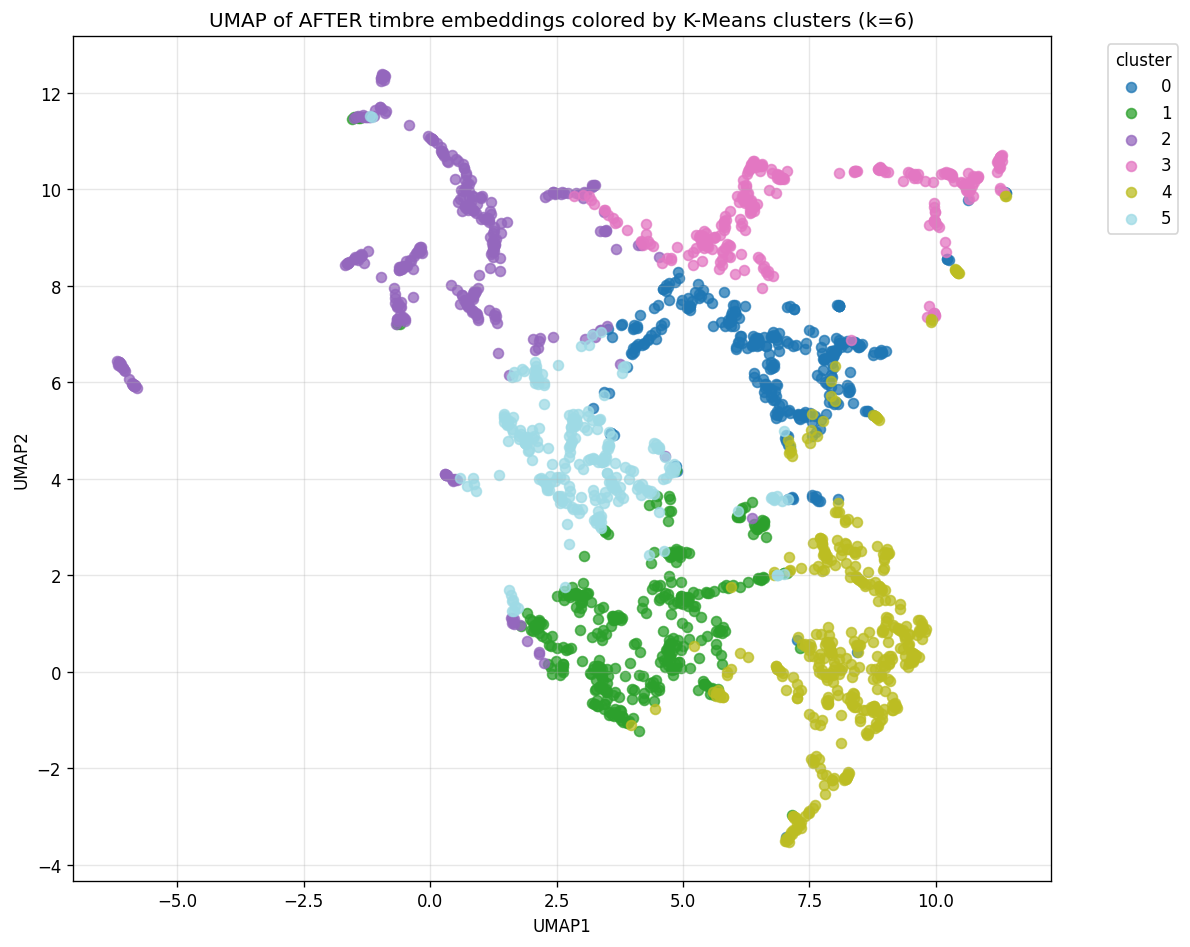

In [ ]:
import umap.umap_ as umap

umap_model = umap.UMAP(
    n_components=2,
    n_neighbors=15,
    min_dist=0.1,
    metric="euclidean",
    random_state=SEED,
)

embeddings_umap = umap_model.fit_transform(embeddings)

print("UMAP shape:", embeddings_umap.shape)

df_umap = make_projection_dataframe(
    df_meta=df_meta,
    coords=embeddings_umap,
    prefix="UMAP",
    cluster_coords=embeddings,  # K-Means on original embeddings
)

display(df_umap.head())

plot_projection_set(df_umap, prefix="UMAP", method_name="UMAP")

## 9. Optional: save metadata and projections

This creates CSV files that can be reused later without recomputing everything.


In [ ]:
df_meta.to_csv(OUTPUT_DIR / f"{SPLIT}_{FEATURE}_metadata.csv", index=False)
df_pca.to_csv(OUTPUT_DIR / f"{SPLIT}_{FEATURE}_pca.csv", index=False)

if "df_tsne" in globals():
    df_tsne.to_csv(OUTPUT_DIR / f"{SPLIT}_{FEATURE}_tsne.csv", index=False)

if "df_umap" in globals():
    df_umap.to_csv(OUTPUT_DIR / f"{SPLIT}_{FEATURE}_umap.csv", index=False)

print("Saved CSV files to:", OUTPUT_DIR.resolve())